In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import seaborn as sns
from binance_data_loader import BinanceDataLoader



In [40]:
data_loader = BinanceDataLoader(
    data_directory="/Users/chinjieheng/Documents/data/binance_dailydata",
    funding_rate_directory="/Users/chinjieheng/Documents/data/binance_fundingrate_data",  # Add this line
    min_records=60,
    min_volume=1e5,
    start_date="2024-01-01",
    end_date=None
)
price_df = data_loader.get_price_matrix()            # index: daily timestamps
returns_df = data_loader.get_returns_matrix()        # index: daily timestamps
funding_long = data_loader.get_funding_long_form()   # MultiIndex (symbol, timestamp) with rate + interval
funding_long = funding_long[funding_long['fundingIntervalHours'] != 1]  # drop any 1h intervals per symbol/timestamp
funding_df = (
    funding_long['fundingRate']
    .unstack(level=0)
    .sort_index()
)   # index: funding event timestamps (full timestamps), columns: symbols

Loading Binance data from /Users/chinjieheng/Documents/data/binance_dailydata (timeframe=1d)...
Found 606 USDT trading pairs
Using a 30-bar rolling window for 30d volume checks
✓ BTCUSDT loaded successfully with 721 records, avg volume: 17,420,296,024
Loaded 570 cryptocurrencies
Filtered 33 cryptocurrencies (insufficient data/volume)
Precomputing returns matrix (FAST numpy version)...
Building returns matrix for 570 tickers over 721 dates...
Precomputed returns matrix shape: (721, 570)
Date range: 2024-01-01 00:00:00 to 2025-12-21 00:00:00
Loading funding rate data from /Users/chinjieheng/Documents/data/binance_fundingrate_data...
Found 608 funding rate files
Loaded funding rates for 570 symbols


In [41]:
daily_funding = funding_df.resample('D').sum(min_count=1)  # Resample to daily frequency by summing up funding rates, min_count=1 to avoid trading NaNs when no funding events
daily_funding["LSKUSDT"]

timestamp
2024-01-01   NaN
2024-01-02   NaN
2024-01-03   NaN
2024-01-04   NaN
2024-01-05   NaN
              ..
2025-12-21   NaN
2025-12-22   NaN
2025-12-23   NaN
2025-12-24   NaN
2025-12-25   NaN
Freq: D, Name: LSKUSDT, Length: 725, dtype: float64

In [42]:
def get_funding_and_vol_summary_daily(daily_funding, price_df, returns_df, start_dt=None, end_dt=None, min_hist_days=30):
    """For each day between start_dt and end_dt, compute the total funding paid/received.
    Return DataFrame with one row per symbol per day"""
    rolling_window = 30  # days for volatility calculation
    
    start_dt = pd.to_datetime(start_dt) if start_dt else None
    end_dt = pd.to_datetime(end_dt) if end_dt else None
    
    # Adjust start date for rolling window warmup
    if start_dt:
        start_dt += pd.Timedelta(days=rolling_window)
    elif start_dt is None:
        start_dt = daily_funding.index.min() + pd.Timedelta(days=rolling_window)
    if end_dt is None:
        end_dt = daily_funding.index.max()

    print("Precomputing dynamic universe matrices...")
    
    # 1. Calculate Rolling Metrics
    valid_counts = price_df.notna().rolling(window=min_hist_days, min_periods=1).sum()
    vol_matrix = returns_df.rolling(window=rolling_window).std() * np.sqrt(365)
    return_matrix = returns_df.abs()

    # 2. Slice to requested date range
    daily_funding_sliced = daily_funding.loc[start_dt:end_dt]
    price_sliced = price_df.loc[start_dt:end_dt]
    valid_counts_sliced = valid_counts.loc[start_dt:end_dt]
    vol_sliced = vol_matrix.loc[start_dt:end_dt]
    return_sliced = return_matrix.loc[start_dt:end_dt]

    print("Applying dynamic universe filter...")

    # 3. Define the Universe Mask (Vectorized Filter)
    # A symbol is valid for a specific day if ALL conditions are met
    universe_mask = (
        (valid_counts_sliced >= min_hist_days) &       # Enough history
        np.isfinite(vol_sliced) &                      # Valid volatility
        np.isfinite(price_sliced) &                    # Valid price
        np.isfinite(daily_funding_sliced)              # Valid funding
    )

    # 4. Extract Data using Numpy (Fast & Simple)
    # Ensure alignment before extracting values (handles potential column mismatches)
    daily_funding_aligned = daily_funding_sliced.reindex_like(universe_mask)
    vol_aligned = vol_sliced.reindex_like(universe_mask)
    return_aligned = return_sliced.reindex_like(universe_mask)

    # Get indices where the mask is True
    mask_values = universe_mask.values
    row_idx, col_idx = np.where(mask_values)

    # Extract values using integer indexing
    dates = universe_mask.index[row_idx]
    symbols = universe_mask.columns[col_idx]
    
    # Construct Result DataFrame
    result_df = pd.DataFrame({
        'date': dates,
        'symbol': symbols,
        'funding_rate_APR': daily_funding_aligned.values[row_idx, col_idx] * 365,
        'annualized_vol': vol_aligned.values[row_idx, col_idx],
        'abs_daily_return': return_aligned.values[row_idx, col_idx]
    })

    print(f"Extracted {len(result_df)} valid rows.")
    
    return result_df.to_dict('records')

In [43]:
daily_summary = pd.DataFrame(
    get_funding_and_vol_summary_daily(
        daily_funding,
        price_df,
        returns_df,
        start_dt="2022-01-01",
        end_dt="2025-01-01"
    )
)
daily_summary

Precomputing dynamic universe matrices...
Applying dynamic universe filter...
Extracted 88584 valid rows.


,date,symbol,funding_rate_APR,annualized_vol,abs_daily_return
0,2024-01-31,1000BONKUSDT,0.109500,1.542444,0.052641
1,2024-01-31,1000FLOKIUSDT,0.109500,1.042017,0.035002
2,2024-01-31,1000LUNCUSDT,0.109500,1.252897,0.026933
3,2024-01-31,1000PEPEUSDT,0.068605,0.964997,0.095413
4,2024-01-31,1000RATSUSDT,0.295818,2.292875,0.146200
...,...,...,...,...,...
88579,2025-01-01,ZETAUSDT,0.099904,1.168625,0.029342
88580,2025-01-01,ZILUSDT,0.109500,1.316757,0.053705
88581,2025-01-01,ZKUSDT,0.109500,1.329954,0.059523
88582,2025-01-01,ZROUSDT,0.109500,1.147157,0.049033


In [44]:

summary_df = daily_summary.sort_values(by='funding_rate_APR')
summary_df['abs_funding_rate_APR'] = summary_df['funding_rate_APR'].abs()
stats = ['funding_rate_APR', 'abs_funding_rate_APR', 'annualized_vol', 'abs_daily_return']
summary_stats = pd.DataFrame()
for stat in stats:
    stats_df = summary_df[[stat]].describe(percentiles=[0.05,0.95]).T
    summary_stats = pd.concat([summary_stats, stats_df], axis=0)

summary_stats

,count,mean,std,min,5%,50%,95%,max
funding_rate_APR,88584.0,0.122188,0.499982,-34.535333,-0.100587,0.109500,0.594994,6.163602
abs_funding_rate_APR,88584.0,0.200371,0.474092,0.000000,0.025700,0.109500,0.660405,34.535333
annualized_vol,88584.0,1.049941,0.466651,0.000000,0.490012,0.986436,1.849910,10.034216
abs_daily_return,88584.0,0.041289,0.043841,0.000000,0.001590,0.030257,0.115916,1.559972


In [45]:
summary_df

,date,symbol,funding_rate_APR,annualized_vol,abs_daily_return,abs_funding_rate_APR
86663,2024-12-26,UXLINKUSDT,-34.535333,2.557679,0.111992,34.535333
77355,2024-11-26,GLMUSDT,-30.608506,0.943978,0.071466,30.608506
20794,2024-04-27,GLMUSDT,-30.578616,1.638776,0.287059,30.578616
23937,2024-05-09,UMAUSDT,-24.044309,1.666408,0.136179,24.044309
39393,2024-07-09,BONDUSDT,-21.921995,1.628246,0.108696,21.921995
...,...,...,...,...,...,...
7581,2024-03-04,1000RATSUSDT,3.354003,1.701421,0.424262,3.354003
7816,2024-03-05,1000RATSUSDT,3.373735,1.969092,0.254456,3.373735
7326,2024-03-02,WIFUSDT,3.562035,3.243337,0.113261,3.562035
7795,2024-03-04,WIFUSDT,3.809724,3.263309,0.084073,3.809724


In [46]:
clean_summary_df = summary_df.loc[:,["symbol"]+stats]
display(clean_summary_df.sort_values(by='abs_funding_rate_APR', ascending=False).head(20))
display(clean_summary_df.sort_values(by='abs_daily_return', ascending=False).head(20))


,symbol,funding_rate_APR,abs_funding_rate_APR,annualized_vol,abs_daily_return
86663,UXLINKUSDT,-34.535333,34.535333,2.557679,0.111992
77355,GLMUSDT,-30.608506,30.608506,0.943978,0.071466
20794,GLMUSDT,-30.578616,30.578616,1.638776,0.287059
23937,UMAUSDT,-24.044309,24.044309,1.666408,0.136179
39393,BONDUSDT,-21.921995,21.921995,1.628246,0.108696
1688,IDUSDT,-21.863500,21.863500,3.150053,0.868637
39138,BONDUSDT,-20.908441,20.908441,1.566821,0.334995
87577,STEEMUSDT,-20.307600,20.307600,2.485000,0.177180
85691,STEEMUSDT,-18.881198,18.881198,1.311481,0.114924
86979,UXLINKUSDT,-18.288916,18.288916,2.593584,0.073183


,symbol,funding_rate_APR,abs_funding_rate_APR,annualized_vol,abs_daily_return
79546,RSRUSDT,0.318882,0.318882,5.505849,1.559972
76503,KSMUSDT,-0.819932,0.819932,3.980488,1.109311
87044,ATAUSDT,-11.613504,11.613504,3.704084,0.999026
79587,TRXUSDT,0.455389,0.455389,3.376516,0.958213
1688,IDUSDT,-21.863500,21.863500,3.150053,0.868637
72399,HMSTRUSDT,0.109500,0.109500,3.020925,0.800841
79608,XVGUSDT,-8.339049,8.339049,3.555171,0.800792
3760,LPTUSDT,-6.547585,6.547585,2.760612,0.773394
76878,SANDUSDT,0.163451,0.163451,3.015266,0.763769
80529,1MBABYDOGEUSDT,0.436248,0.436248,2.770273,0.752491


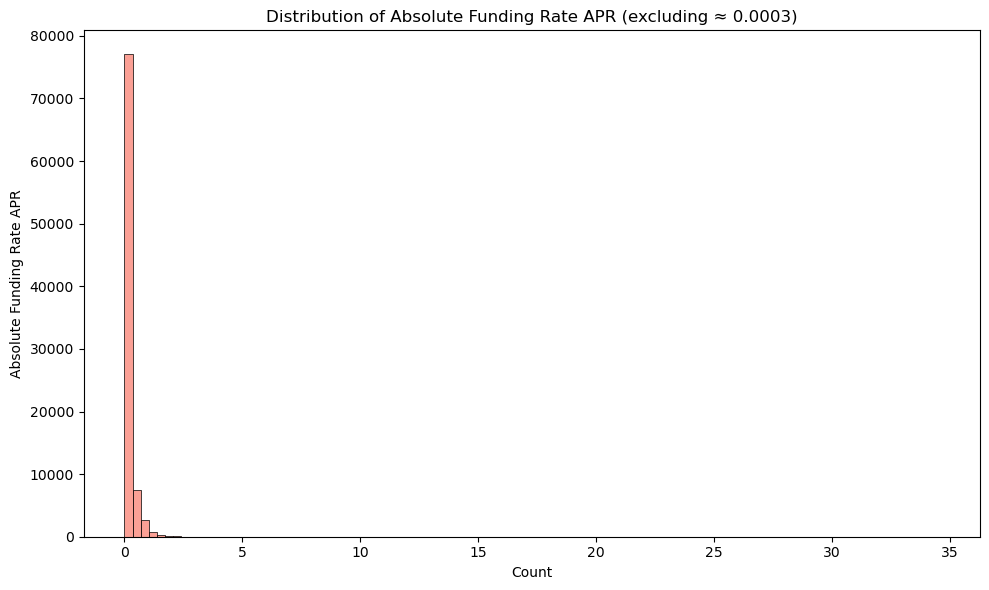

In [47]:
# Filter out rows where funding_rate_APR is approximately 0.0003
filter_value = 0.0003
tol = 1e-9  # tolerance for comparison; adjust if needed
plot_df = clean_summary_df.loc[~np.isclose(clean_summary_df['funding_rate_APR'], filter_value, atol=tol)].copy()

plt.figure(figsize=(10,6))
sns.histplot(data=plot_df, x='abs_funding_rate_APR', bins=100, color='salmon', orientation='horizontal')
plt.title(f"Distribution of Absolute Funding Rate APR (excluding ≈ {filter_value})")
plt.xlabel('Count')
plt.ylabel('Absolute Funding Rate APR')
plt.tight_layout()
plt.show()

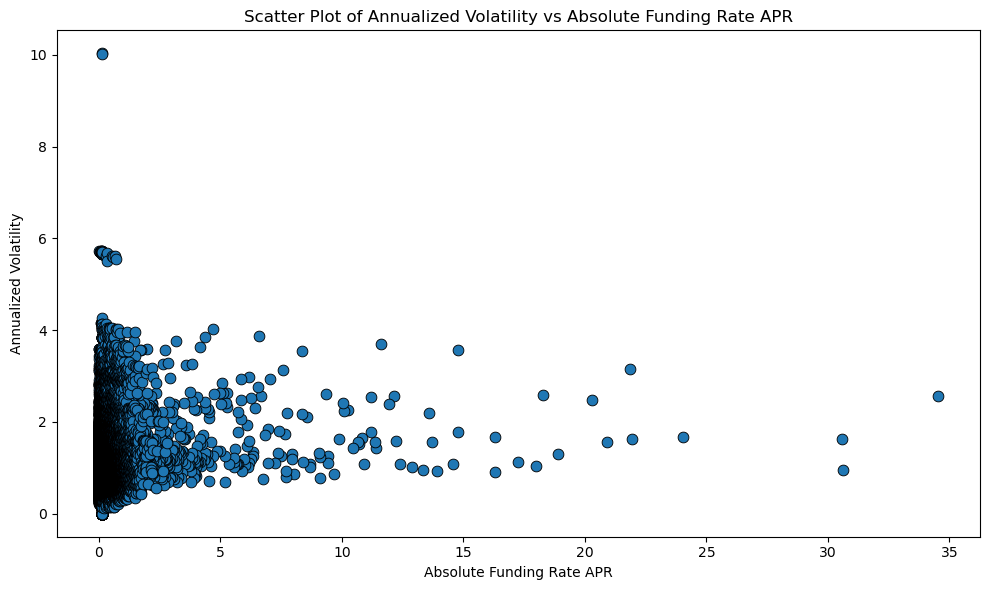

In [48]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=clean_summary_df, y='annualized_vol', x='abs_funding_rate_APR', s=60, edgecolor='k')
plt.title("Scatter Plot of Annualized Volatility vs Absolute Funding Rate APR")
plt.xlabel('Absolute Funding Rate APR')
plt.ylabel('Annualized Volatility')
plt.tight_layout()
plt.show()

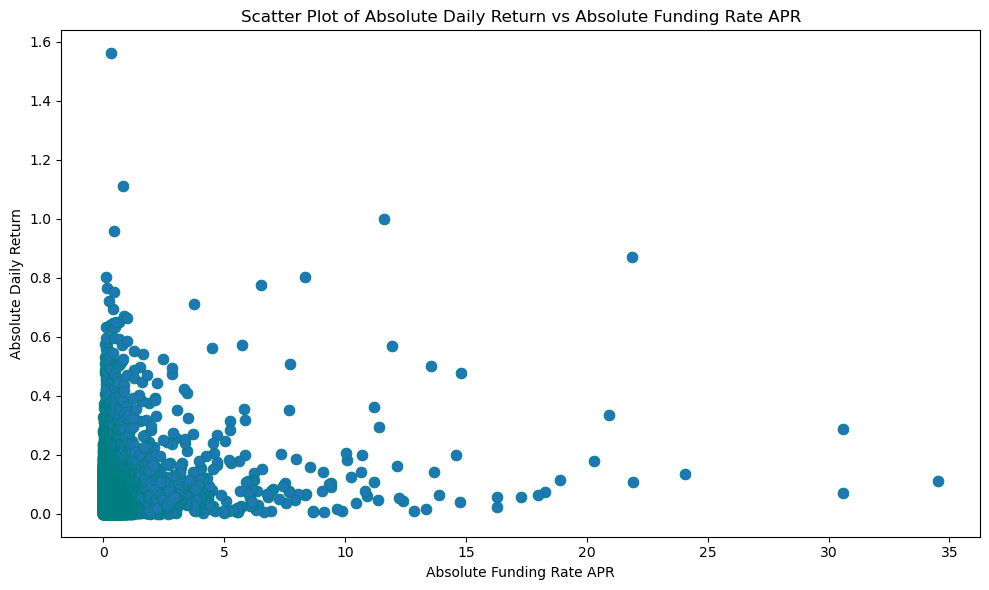

In [49]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=clean_summary_df, x='abs_funding_rate_APR', y='abs_daily_return', s=60, edgecolor='teal')
plt.title("Scatter Plot of Absolute Daily Return vs Absolute Funding Rate APR")
plt.xlabel('Absolute Funding Rate APR')
plt.ylabel('Absolute Daily Return')
plt.tight_layout()
plt.show()

In [50]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.ar_model import AutoReg
import cvxpy as cvx

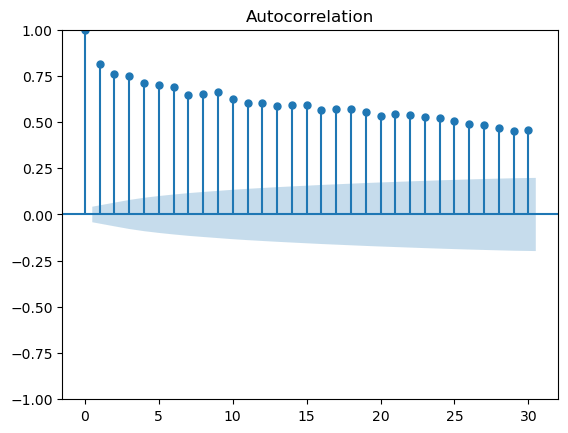

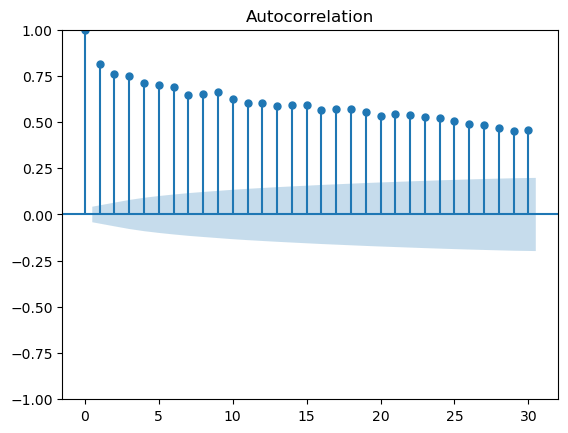

In [51]:
plot_acf(funding_df['BTCUSDT'].dropna(), lags=30)

In [52]:
def analyze_pacf_top_20(start_dt=None, end_dt=None):
    """Compute and plot PACF for top 20 symbols by absolute funding rate APR
    Return:
    -pacf_df df with pacf per coin
    -top 20 symbols list
    -annualized funding: Series of annualized funding (APR) of all pairs"""

    if start_dt is None:
        start_dt = funding_df.index.min()
    if end_dt is None:
        end_dt = funding_df.index.max()
    filtered_funding_rate = daily_funding.loc[start_dt:end_dt]

    #compute mean funding rate APR for each pair in this window
    mean_apr = filtered_funding_rate.mean() * 365
    top_20 = mean_apr.abs().sort_values(ascending=False).head(25).index.tolist()

    #calculate pacf for each of the top 20 symbols
    pacf_dict = {}
    for symbol in top_20:
        if len(filtered_funding_rate[symbol].dropna()) > 30:
            try:
                pacf_values = pacf(filtered_funding_rate[symbol].dropna(), nlags=7, method='yw')
                pacf_dict[symbol] = pacf_values
            except Exception as e:
                print(f"Error computing PACF for {symbol}: {e}")
            

    pacf_df = pd.DataFrame(pacf_dict).T
    return pacf_df, top_20, mean_apr

pacf_by_pairs_top_20, top_20_pairs, mean_apr = analyze_pacf_top_20(start_dt="2024-01-01", end_dt="2025-01-01")
print("Top 20 pairs by absolute funding rate APR:")
print(top_20_pairs)
pacf_by_pairs_top_20    

Top 20 pairs by absolute funding rate APR:
['HIVEUSDT', 'MOCAUSDT', 'VANAUSDT', 'MOVEUSDT', 'UXLINKUSDT', 'BANUSDT', 'HIPPOUSDT', 'RAREUSDT', '1000WHYUSDT', '1000CHEEMSUSDT', 'GOATUSDT', 'GLMUSDT', 'CHILLGUYUSDT', 'DEGENUSDT', 'KOMAUSDT', 'DFUSDT', 'MOODENGUSDT', 'AIXBTUSDT', '1000RATSUSDT', '1000000MOGUSDT', 'USUALUSDT', 'NEIROETHUSDT', 'AKTUSDT', 'PHAUSDT', 'POPCATUSDT']


,0,1,2,3,4,5,6,7
UXLINKUSDT,1.0,0.659628,-0.224679,0.122972,-0.141076,0.042812,0.018558,0.033583
BANUSDT,1.0,0.663865,-0.045138,0.172735,-0.100433,0.021865,-0.207160,0.077827
HIPPOUSDT,1.0,0.694919,0.014333,0.371953,-0.071122,0.105840,-0.141699,-0.107034
RAREUSDT,1.0,0.793516,-0.597746,0.430920,-0.142073,-0.113818,0.141480,-0.025520
1000WHYUSDT,1.0,0.760955,0.129786,0.294123,0.104320,-0.019907,-0.177488,-0.038840
1000CHEEMSUSDT,1.0,0.842777,-0.057143,0.194895,0.105228,0.170011,-0.282828,-0.092972
GOATUSDT,1.0,0.686435,0.402368,-0.043370,0.197237,-0.082876,-0.167602,-0.022482
GLMUSDT,1.0,0.475865,-0.077745,-0.037114,0.011576,-0.002697,0.015391,-0.004567
CHILLGUYUSDT,1.0,0.734355,-0.021121,-0.078643,0.421113,-0.140551,0.044470,0.318886
DEGENUSDT,1.0,0.751132,-0.252372,0.206821,-0.134130,0.028489,0.059855,-0.014664


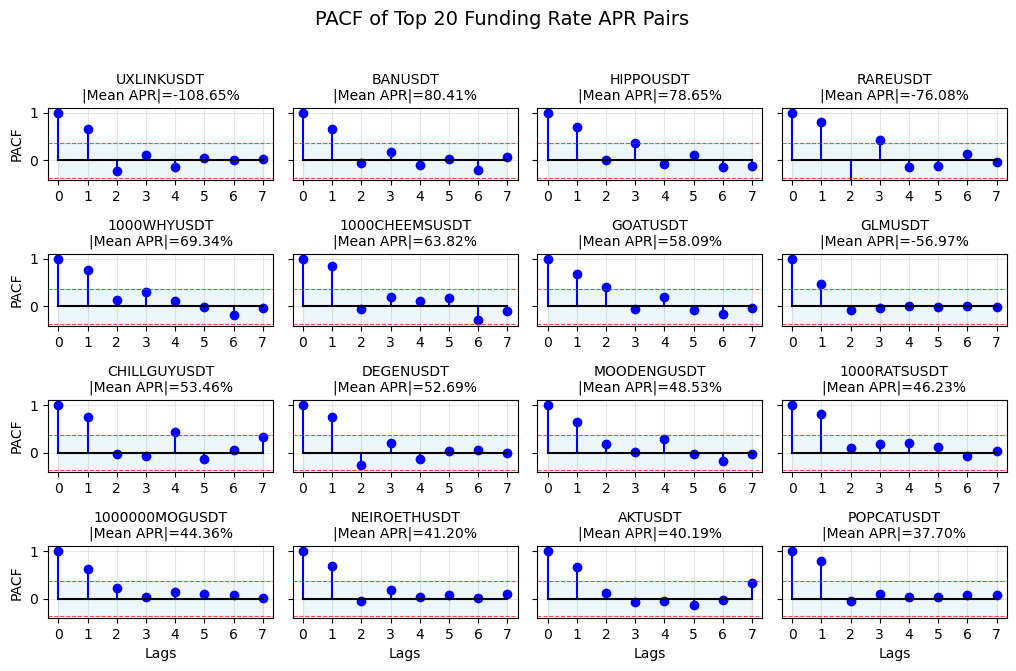

In [53]:
def plot_pacf_by_pairs(pacf_by_pair, top_20_pairs, mean_apr, n_cols=4):
    """"Plot PACF for the top 20 funding rate APR pairs as a small multiple(faceted) grid of classical PACF plots.
    plots are sorted in descending order of absolute mean funding rate APR.
    """

    # Filter top_20_pairs to only include those present in pacf_by_pair
    available_pairs = [pair for pair in top_20_pairs if pair in pacf_by_pair.index]
    
    if not available_pairs:
        print("No pairs available to plot.")
        return

    sorted_pairs = mean_apr.loc[available_pairs].abs().sort_values(ascending=False).index.tolist()

    n_pairs = len(sorted_pairs)
    n_rows = (n_pairs + n_cols - 1) // n_cols  # Ceiling division to determine number of rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6*n_cols, 1.7*n_rows), sharey=True)
    axes = axes.flatten()  # Flatten in case of multiple rows

    for i, pair in enumerate(sorted_pairs):
        ax = axes[i]
        pacf_vals = pacf_by_pair.loc[pair, : 7]

        #Crete bar plot for PACF values Classical style
        ax.stem(range(7+1), pacf_vals, linefmt="b-", markerfmt="bo", basefmt="k-")
        conf_interval = 1.96 / np.sqrt(max(len(pacf_vals),30)) # 95% confidence interval estimate for sample count
        ax.axhline(y=conf_interval, linestyle='--', color='red', alpha=0.7, linewidth=0.8)
        ax.axhline(y=-conf_interval, linestyle='--', color='red', alpha=0.7, linewidth=0.8)
        #Add shading for confidence interval
        ax.fill_between(range(7+1), conf_interval, -conf_interval, color='lightblue', alpha=0.22)
        apr = mean_apr.loc[pair] *100
        ax.set_title(f"{pair}\n|Mean APR|={apr:.2f}%", fontsize=10)
        ax.set_xticks(range(7+1))
        ax.set_ylim(-0.4,1.1)
        ax.grid(True, alpha=0.3)

        if i%n_cols == 0:
            ax.set_ylabel("PACF", fontsize=10)
        if i >= (n_rows-1)*n_cols:
            ax.set_xlabel("Lags", fontsize=10)

    #IF less than n_rows*n_cols, turn off extra axes
    for j in range(i+1, n_rows*n_cols):
        axes[j].axis('off')

    plt.suptitle("PACF of Top 20 Funding Rate APR Pairs", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust rect to make room for suptitle
    plt.show()

plot_pacf_by_pairs(pacf_by_pairs_top_20, top_20_pairs, mean_apr)

In [54]:
IN_SAMPLE_START_DATE = "2024-01-01"
IN_SAMPLE_END_DATE = "2024-12-31"

In [55]:
def robust_ar_1_fit(funding_rates):
    """Robust AR(1) fitting with fallback to manual estimation,
    Assure input to AR fit does not contain inf/nan prevents Runtime error"""

    if len(funding_rates) < 30:
        return None
    
    #Will Still warn if contain nan, so check again explicitly
    if not np.all(np.isfinite(funding_rates)):
        raise ValueError("Input returns to AutoReg contain non-finite values!")
    
    model = AutoReg(funding_rates, lags=1, old_names=False).fit()
    if hasattr(model, 'params') and len(model.params) == 2: #AR(1) + constant
        return model
    

def calculate_ar1_factor_custom_dates(symbols, current_day):
    """Calculate AR(1)  factor for a specific coin using custom start and 30 day lookback
    Extra nan/inf handling for all returns, prevents warnings downsstream"""

    print(f"Calculating AR(1) factor for {symbols} on {current_day}")

    if isinstance(current_day, str):
        current_day = pd.to_datetime(current_day)

    train_start =  pd.to_datetime(IN_SAMPLE_START_DATE)
    if (current_day - train_start) < pd.Timedelta(days=30):
        print("Error: current day must be at least 30 days after train start date for lookback")
        return {}
    
    ar1_results = {}
    relevant_funding_rate = daily_funding[(daily_funding.index > current_day - pd.Timedelta(days=30)) & 
                                            (daily_funding.index <= current_day)].sort_index().reset_index(drop=True)
    for symbol in symbols:
        symbol_rates = relevant_funding_rate[symbol].copy()

        if symbol_rates.empty or len(symbol_rates) < 30:
            ar1_results[symbol] = np.nan
            continue

        funding_rate = symbol_rates.values

        #Remove nan/inf BEFORE  len check
        funding_rate = funding_rate[np.isfinite(funding_rate)]

        if len(funding_rate) < 30:
            ar1_results[symbol] = np.nan
            continue

        #Check for all zero
        if np.std(funding_rate) < 1e-10:
            ar1_results[symbol] = np.nan
            continue

        #Final inf/nan check
        if not np.all(np.isfinite(funding_rate)):
            ar1_results[symbol] = np.nan
            continue

        ar1_model = robust_ar_1_fit(funding_rate)

        if ar1_model is not None:
            ar1_results[symbol] = {
                'intercept':ar1_model.params[0],
                'ar1_factor':ar1_model.params[1]
            }

    return ar1_results

In [56]:
ar1_factors_list = []
for days in daily_funding.index:
    ar1_results_for_day =  calculate_ar1_factor_custom_dates(daily_funding.columns, days)
    if ar1_results_for_day:
        for symbol, res in ar1_results_for_day.items():
            if isinstance(res, dict) and ('ar1_factor' in res) and ('intercept' in res):
                day_df = pd.DataFrame([{                    
                    'symbol': symbol,
                    'intercept': res['intercept'],
                    'ar1_factor': res['ar1_factor'],
                    'date': days,
                }])
                ar1_factors_list.append(day_df)

if ar1_factors_list:
    ar1_factors = pd.concat(ar1_factors_list, ignore_index=True)
else:
    ar1_factors = pd.DataFrame()

#ar1_factors.to_csv("ar1_factors_daily.csv", index=False)
ar1_factors

Calculating AR(1) factor for Index(['0GUSDT', '1000000BOBUSDT', '1000000MOGUSDT', '1000BONKUSDT',
       '1000CATUSDT', '1000CHEEMSUSDT', '1000FLOKIUSDT', '1000LUNCUSDT',
       '1000PEPEUSDT', '1000RATSUSDT',
       ...
       'ZETAUSDT', 'ZILUSDT', 'ZKCUSDT', 'ZKJUSDT', 'ZKUSDT', 'ZORAUSDT',
       'ZRCUSDT', 'ZROUSDT', 'ZRXUSDT', '币安人生USDT'],
      dtype='object', name='symbol', length=570) on 2024-01-01 00:00:00
Error: current day must be at least 30 days after train start date for lookback
Calculating AR(1) factor for Index(['0GUSDT', '1000000BOBUSDT', '1000000MOGUSDT', '1000BONKUSDT',
       '1000CATUSDT', '1000CHEEMSUSDT', '1000FLOKIUSDT', '1000LUNCUSDT',
       '1000PEPEUSDT', '1000RATSUSDT',
       ...
       'ZETAUSDT', 'ZILUSDT', 'ZKCUSDT', 'ZKJUSDT', 'ZKUSDT', 'ZORAUSDT',
       'ZRCUSDT', 'ZROUSDT', 'ZRXUSDT', '币安人生USDT'],
      dtype='object', name='symbol', length=570) on 2024-01-02 00:00:00
Error: current day must be at least 30 days after train start date for lookback


,symbol,intercept,ar1_factor,date
0,1000BONKUSDT,0.000211,0.304590,2024-01-31
1,1000FLOKIUSDT,0.000125,0.328451,2024-01-31
2,1000LUNCUSDT,0.000173,0.274511,2024-01-31
3,1000PEPEUSDT,0.000166,0.400282,2024-01-31
4,1000RATSUSDT,0.000787,0.264899,2024-01-31
...,...,...,...,...
232804,ZORAUSDT,-0.000375,0.761258,2025-12-25
232805,ZRCUSDT,0.000384,-0.039368,2025-12-25
232806,ZROUSDT,-0.000280,0.588471,2025-12-25
232807,ZRXUSDT,-0.000782,-0.148666,2025-12-25


In [57]:
# Melt daily_funding to long format to merge with ar1_factors
daily_funding_long = daily_funding.stack().reset_index()
daily_funding_long.columns = ['date', 'symbol', 'funding_rate']

# Merge ar1_factors with current day's funding rate
funding_rate_forecast = pd.merge(
    ar1_factors,
    daily_funding_long,
    on=['date', 'symbol'],
    how='inner'
)

# Calculate predicted funding rate for the NEXT day (t+1) using model fit on data up to t
# y_{t+1} = alpha + beta * y_t
funding_rate_forecast['predicted_funding_rate'] = (
    funding_rate_forecast['intercept'] + 
    funding_rate_forecast['ar1_factor'] * funding_rate_forecast['funding_rate']
)

funding_rate_forecast = funding_rate_forecast.drop(columns=['intercept', 'ar1_factor'])
funding_rate_forecast

,symbol,date,funding_rate,predicted_funding_rate
0,1000BONKUSDT,2024-01-31,0.000300,0.000302
1,1000FLOKIUSDT,2024-01-31,0.000300,0.000224
2,1000LUNCUSDT,2024-01-31,0.000300,0.000256
3,1000PEPEUSDT,2024-01-31,0.000188,0.000241
4,1000RATSUSDT,2024-01-31,0.000810,0.001001
...,...,...,...,...
232804,ZORAUSDT,2025-12-25,-0.000103,-0.000453
232805,ZRCUSDT,2025-12-25,0.000368,0.000370
232806,ZROUSDT,2025-12-25,0.000015,-0.000271
232807,ZRXUSDT,2025-12-25,0.000037,-0.000788


In [ ]:
btc_rets = returns_df['BTCUSDT']
eth_rets = returns_df['ETHUSDT']
combined_rets = (btc_rets+eth_rets)/2

window = 30

rolling_cov_btc = returns_df.rolling(window).cov(btc_rets)
rolling_var_btc = btc_rets.rolling(window).var()
beta_btc = rolling_cov_btc.div(rolling_var_btc, axis=0)

rolling_cov_eth = returns_df.rolling(window).cov(eth_rets)
rolling_var_eth = eth_rets.rolling(window).var()
beta_eth = rolling_cov_eth.div(rolling_var_eth, axis=0)

rolling_cov_combined = returns_df.rolling(window).cov(combined_rets)
rolling_var_combined = combined_rets.rolling(window).var()
beta_combined = rolling_cov_combined.div(rolling_var_combined, axis=0)


beta_btc_long = beta_btc.stack().rename("btc_beta")
beta_eth_long = beta_eth.stack().rename("eth_beta")
beta_combined_long = beta_combined.stack().rename("combined_beta")


daily_betas = pd.concat([beta_btc_long, beta_eth_long, beta_combined_long], axis=1)
daily_betas.index = daily_betas.index.set_names(['date','symbol'])

daily_betas.loc[
    daily_betas.index.get_level_values('symbol').isin(['BTCUSDT','ETHUSDT']),
    ['btc_beta','eth_beta','combined_beta']
] = np.nan

daily_betas = daily_betas.reset_index().set_index("date")


In [59]:
daily_betas



,symbol,btc_beta,eth_beta,combined_beta
date,,,,
2024-01-31,1000BONKUSDT,1.815730,1.799111,2.132160
2024-01-31,1000FLOKIUSDT,1.106148,1.073863,1.284038
2024-01-31,1000LUNCUSDT,1.667351,1.501934,1.857101
2024-01-31,1000PEPEUSDT,1.316577,1.322955,1.558393
2024-01-31,1000RATSUSDT,2.396375,2.177634,2.681850
...,...,...,...,...
2025-12-21,ZORAUSDT,1.719036,0.959654,1.331337
2025-12-21,ZRCUSDT,0.986060,0.494212,0.719134
2025-12-21,ZROUSDT,1.288909,0.938553,1.171609


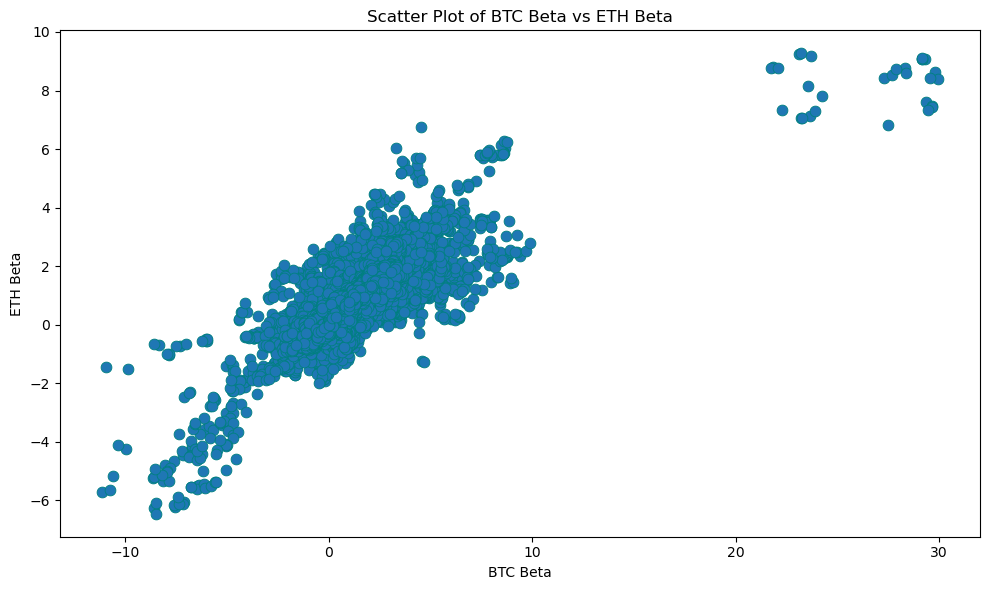

In [60]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=daily_betas.reset_index(), x='btc_beta', y='eth_beta', s=60, edgecolor='teal')
plt.title("Scatter Plot of BTC Beta vs ETH Beta")
plt.xlabel('BTC Beta')
plt.ylabel('ETH Beta')
plt.tight_layout()
plt.show()

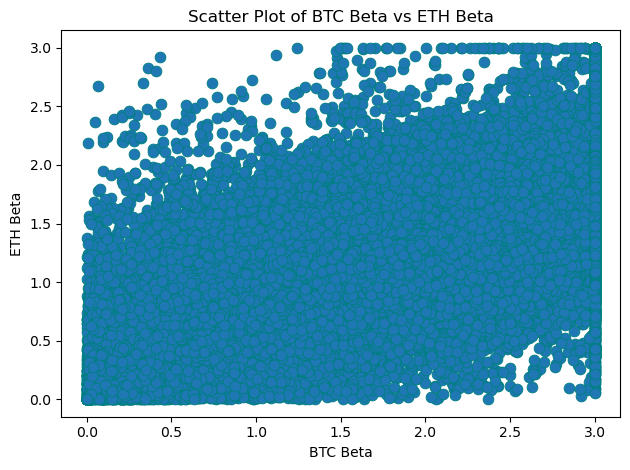

In [61]:
daily_betas['btc_beta'] = abs(daily_betas['btc_beta'].clip(-3,3))
daily_betas['eth_beta'] = abs(daily_betas['eth_beta'].clip(-3,3))
daily_betas['combined_beta'] = abs(daily_betas['combined_beta'].clip(-3,3))

sns.scatterplot(data=daily_betas.reset_index(), x='btc_beta', y='eth_beta', s=60, edgecolor='teal')
plt.title("Scatter Plot of BTC Beta vs ETH Beta")
plt.xlabel('BTC Beta')
plt.ylabel('ETH Beta')
plt.tight_layout()
plt.show()

In [62]:
def build_beta_neutral_portfolio(predicted_funding_rates, betas, beta_limit=1e-4):
    #align data
    idx = predicted_funding_rates.index.intersection(betas.index)
    s = predicted_funding_rates.loc[idx].fillna(0).values
    b = betas.loc[idx].fillna(0).values
    n = len(idx)

    if n == 0:
        return pd.Series(dtype=float)
    
    #Define optimization variables
    w = cvx.Variable(n)

    #Define objective: maximize expected funding pnl
    objective = cvx.Maximize(-s @ w)

    #Define constraints: beta neutrality and weight limits
    constraints = [
        cvx.abs(b @ w) <= beta_limit, #beta neutrality constraint
        cvx.norm1(w) <= 1      #normalize gross exposure
    ]

    #Define and solve problem
    prob = cvx.Problem(objective, constraints)
    prob.solve(solver=cvx.CLARABEL, verbose=False)

    #return as a pandas Series
    if w.value is None:
        #fall back to equal weights if optimization fails
        w_sol = np.zeros(n)
    else:
        w_sol = w.value

    return pd.Series(w_sol, index=idx)

In [63]:
# Build Open Price Matrix
print("Building Open Price Matrix...")
open_price_df = pd.DataFrame(index=price_df.index, columns=price_df.columns)
for ticker in price_df.columns:
    if ticker in data_loader._crypto_universe:
        data = data_loader._crypto_universe[ticker]['data']
        if data.index.duplicated().any():
            data = data[~data.index.duplicated(keep='last')]
        # Reindex to match price_df index (daily)
        open_price_df[ticker] = data['open'].reindex(price_df.index)
print("Open Price Matrix Built.")

#Backtest
portfolio_size_each_side = 5

# Track both additive PnL (legacy) and multiplicative equity curves
price_pnl_total_add = [0.0]
funding_pnl_total_add = [0.0]
total_pnl_add = [0.0]
price_equity_curve = [1.0]
funding_equity_curve = [1.0]
total_equity_curve = [1.0]

# FIX: Ensure funding_rate_forecast is indexed by date for .loc[index] to work
if 'date' in funding_rate_forecast.columns:
    funding_rate_forecast = funding_rate_forecast.set_index('date')

IN_SAMPLE = pd.date_range(
    start=IN_SAMPLE_START_DATE,
    end=IN_SAMPLE_END_DATE,
    freq='D'
)

for index in IN_SAMPLE[window:]:
    #Get forecast and beta
    cur_predicted_funding = (
        funding_rate_forecast.loc[index]
        .set_index('symbol')["predicted_funding_rate"]
        .fillna(0)
    )

    cur_beta = (
        daily_betas.loc[index]
        .set_index('symbol')['combined_beta']
    )
    
    # FIX: Align the two series to ensure they have the same symbols before filtering
    # This fixes the "Unalignable boolean Series" error while keeping your loop structure
    cur_predicted_funding, cur_beta = cur_predicted_funding.align(cur_beta, join='inner')

    valid_mask = cur_beta.notna()

    cur_predicted_funding = cur_predicted_funding.loc[valid_mask]
    cur_beta = cur_beta.loc[valid_mask]

    try:
        # Use Open prices for trading logic to match vertox_version
        cur_prices = open_price_df.loc[index]
        next_prices = open_price_df.loc[index + pd.Timedelta(days=1)]

        next_funding = daily_funding.loc[index + pd.Timedelta(days=1)]
    
    except KeyError:
        continue

    available_pairs = list(
        set(cur_predicted_funding.index)
        & set(cur_beta.index)
        & set(cur_prices.index)
        & set(next_prices.index)
        & set(next_funding.index)
    )

    if len(available_pairs) < 2*portfolio_size_each_side:
        #Not enough pairs to build portfolio
        continue

    #restrict to available pairs
    cur_predicted_funding = cur_predicted_funding.loc[available_pairs]
    cur_beta = cur_beta.loc[available_pairs]
    cur_prices = cur_prices.loc[available_pairs]
    next_prices = next_prices.loc[available_pairs]
    next_funding = next_funding.loc[available_pairs]

    #Select top/bottom N pairs by predicted funding
    cur_predicted_funding = cur_predicted_funding.sort_values(ascending=False)
    highest = cur_predicted_funding.head(portfolio_size_each_side)
    lowest = cur_predicted_funding.tail(portfolio_size_each_side)
    
    # FIX: Use .index.union() because Series objects don't have .union()
    trade_universe = highest.index.union(lowest.index)

    #Restrict optimizer to select names
    s = cur_predicted_funding.loc[trade_universe]
    b = cur_beta.loc[trade_universe]

    #optimization
    positions = build_beta_neutral_portfolio(s, b)

    #Pnl computation
    # Calculate price changes using Open prices (Open-to-Open return)
    price_changes = ((next_prices - cur_prices) / cur_prices).fillna(0)
    price_changes = price_changes[trade_universe]
    
    # Explicitly align price_changes to positions index before multiplying
    price_return = (positions * price_changes.reindex(positions.index)).sum()
    funding_return = -(positions * next_funding.reindex(positions.index)).sum()
    daily_total_return = price_return + funding_return

    # Additive tracking (legacy cumulative PnL)
    price_pnl_total_add.append(price_pnl_total_add[-1] + price_return)
    funding_pnl_total_add.append(funding_pnl_total_add[-1] + funding_return)
    total_pnl_add.append(total_pnl_add[-1] + daily_total_return)

    # Multiplicative compounding of returns
    price_equity_curve.append(price_equity_curve[-1] * (1 + price_return))
    funding_equity_curve.append(funding_equity_curve[-1] * (1 + funding_return))
    total_equity_curve.append(total_equity_curve[-1] * (1 + daily_total_return))

# Convert to arrays and expose both styles
price_pnl_total = np.array(price_equity_curve) - 1
funding_pnl_total = np.array(funding_equity_curve) - 1
total_pnl_total = np.array(total_equity_curve) - 1
price_pnl_total_add = np.array(price_pnl_total_add)
funding_pnl_total_add = np.array(funding_pnl_total_add)
total_pnl_add = np.array(total_pnl_add)

Building Open Price Matrix...
Open Price Matrix Built.


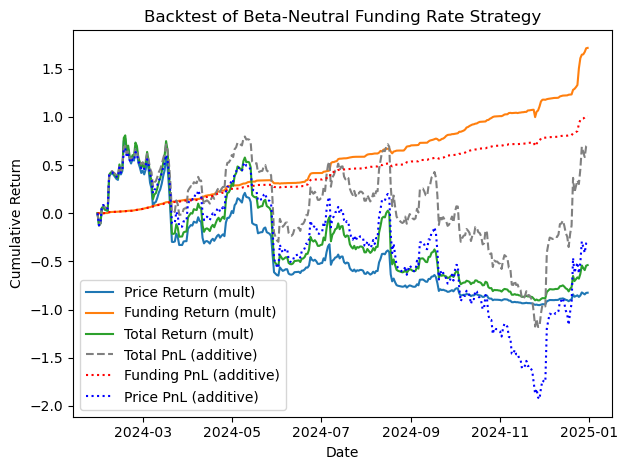

In [64]:
dates = IN_SAMPLE[window-1:window-1+len(price_pnl_total)]
if len(dates) != len(price_pnl_total):
    m = min(len(dates), len(price_pnl_total))
    dates = dates[:m]
    price_plot = price_pnl_total[:m]
    funding_plot = funding_pnl_total[:m]
    total_mult_plot = total_pnl_total[:m]
    total_add_plot = total_pnl_add[:m]
else:
    price_plot = price_pnl_total
    funding_plot = funding_pnl_total
    total_mult_plot = total_pnl_total
    total_add_plot = total_pnl_add

plt.plot(dates, price_plot, label='Price Return (mult)')
plt.plot(dates, funding_plot, label='Funding Return (mult)')
plt.plot(dates, total_mult_plot, label='Total Return (mult)')
plt.plot(dates, total_add_plot, '--', color='gray', label='Total PnL (additive)')
plt.plot(dates, funding_pnl_total_add[:len(dates)], ':', color='red', label='Funding PnL (additive)')
plt.plot(dates, price_pnl_total_add[:len(dates)], ':', color='blue', label='Price PnL (additive)')
plt.legend()
plt.title("Backtest of Beta-Neutral Funding Rate Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.tight_layout()
plt.show()

In [65]:
OUT_SAMPLE_START_DATE = "2025-01-02"
OUT_SAMPLE_END_DATE = "2025-10-01"

In [66]:
#Backtest
portfolio_size_each_side = 5

# Track both additive PnL (legacy) and multiplicative equity curves
price_pnl_total_add = [0.0]
funding_pnl_total_add = [0.0]
total_pnl_add = [0.0]
price_equity_curve = [1.0]
funding_equity_curve = [1.0]
total_equity_curve = [1.0]

# FIX: Ensure funding_rate_forecast is indexed by date for .loc[index] to work
if 'date' in funding_rate_forecast.columns:
    funding_rate_forecast = funding_rate_forecast.set_index('date')

OUT_SAMPLE = pd.date_range(
    start=OUT_SAMPLE_START_DATE,
    end=OUT_SAMPLE_END_DATE,
    freq='D'
)

for index in OUT_SAMPLE[window:]:
    #Get forecast and beta
    cur_predicted_funding = (
        funding_rate_forecast.loc[index]
        .set_index('symbol')["predicted_funding_rate"]
        .fillna(0)
    )

    cur_beta = (
        daily_betas.loc[index]
        .set_index('symbol')['combined_beta']
    )
    
    # FIX: Align the two series to ensure they have the same symbols before filtering
    # This fixes the "Unalignable boolean Series" error while keeping your loop structure
    cur_predicted_funding, cur_beta = cur_predicted_funding.align(cur_beta, join='inner')

    valid_mask = cur_beta.notna()

    cur_predicted_funding = cur_predicted_funding.loc[valid_mask]
    cur_beta = cur_beta.loc[valid_mask]

    try:
        cur_prices = price_df.loc[index]
        next_prices = price_df.loc[index + pd.Timedelta(days=1)]

        next_funding = daily_funding.loc[index + pd.Timedelta(days=1)]
    
    except KeyError:
        continue

    available_pairs = list(
        set(cur_predicted_funding.index)
        & set(cur_beta.index)
        & set(cur_prices.index)
        & set(next_prices.index)
        & set(next_funding.index)
    )

    if len(available_pairs) < 2*portfolio_size_each_side:
        #Not enough pairs to build portfolio
        continue

    #restrict to available pairs
    cur_predicted_funding = cur_predicted_funding.loc[available_pairs]
    cur_beta = cur_beta.loc[available_pairs]
    cur_prices = cur_prices.loc[available_pairs]
    next_prices = next_prices.loc[available_pairs]
    next_funding = next_funding.loc[available_pairs]

    #Select top/bottom N pairs by predicted funding
    cur_predicted_funding = cur_predicted_funding.sort_values(ascending=False)
    highest = cur_predicted_funding.head(portfolio_size_each_side)
    lowest = cur_predicted_funding.tail(portfolio_size_each_side)
    
    # FIX: Use .index.union() because Series objects don't have .union()
    trade_universe = highest.index.union(lowest.index)

    #Restrict optimizer to select names
    s = cur_predicted_funding.loc[trade_universe]
    b = cur_beta.loc[trade_universe]

    #optimization
    positions = build_beta_neutral_portfolio(s, b)

    #Pnl computation
    price_changes = returns_df.loc[index + pd.Timedelta(days=1), trade_universe]
    
    # Explicitly align price_changes to positions index before multiplying
    price_return = (positions * price_changes.reindex(positions.index)).sum()
    funding_return = -(positions * next_funding.reindex(positions.index)).sum()
    daily_total_return = price_return + funding_return

    # Additive tracking (legacy cumulative PnL)
    price_pnl_total_add.append(price_pnl_total_add[-1] + price_return)
    funding_pnl_total_add.append(funding_pnl_total_add[-1] + funding_return)
    total_pnl_add.append(total_pnl_add[-1] + daily_total_return)

    # Multiplicative compounding of returns
    price_equity_curve.append(price_equity_curve[-1] * (1 + price_return))
    funding_equity_curve.append(funding_equity_curve[-1] * (1 + funding_return))
    total_equity_curve.append(total_equity_curve[-1] * (1 + daily_total_return))

# Convert to arrays and expose both styles
price_pnl_total = np.array(price_equity_curve) - 1
funding_pnl_total = np.array(funding_equity_curve) - 1
total_pnl_total = np.array(total_equity_curve) - 1
price_pnl_total_add = np.array(price_pnl_total_add)
funding_pnl_total_add = np.array(funding_pnl_total_add)
total_pnl_add = np.array(total_pnl_add)

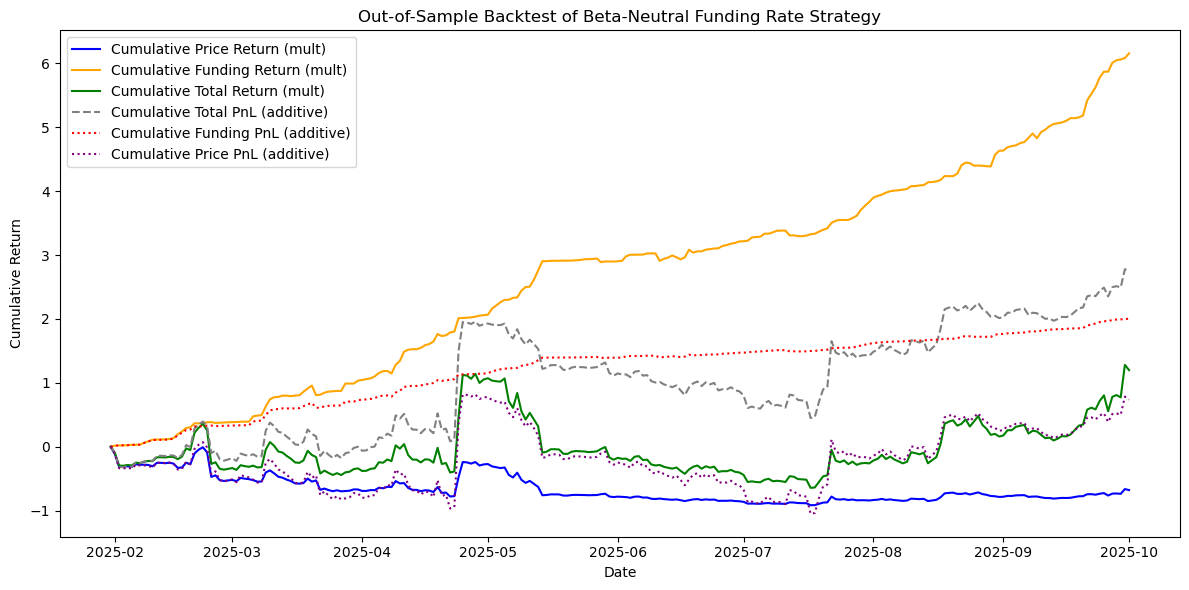

In [67]:
dates = OUT_SAMPLE[window-1:window-1+len(price_pnl_total)]
if len(dates) != len(price_pnl_total):
    m = min(len(dates), len(price_pnl_total))
    dates = dates[:m]
    price_plot = price_pnl_total[:m]
    funding_plot = funding_pnl_total[:m]
    total_mult_plot = total_pnl_total[:m]
else:
    price_plot = price_pnl_total
    funding_plot = funding_pnl_total
    total_mult_plot = total_pnl_total

plt.figure(figsize=(12,6))
plt.plot(dates, price_plot, label='Cumulative Price Return (mult)', color='blue')
plt.plot(dates, funding_plot, label='Cumulative Funding Return (mult)', color='orange')
plt.plot(dates, total_mult_plot, label='Cumulative Total Return (mult)', color='green')
plt.plot(dates, total_pnl_add[:len(dates)], '--', color='gray', label='Cumulative Total PnL (additive)')
plt.plot(dates, funding_pnl_total_add[:len(dates)], ':', color='red', label='Cumulative Funding PnL (additive)')
plt.plot(dates, price_pnl_total_add[:len(dates)], ':', color='purple', label='Cumulative Price PnL (additive)')
plt.legend()
plt.title("Out-of-Sample Backtest of Beta-Neutral Funding Rate Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.tight_layout()
plt.show()